In [21]:
import pandas as pd
df = pd.read_csv('reto.csv')
import matplotlib.pyplot as plt
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


x=9

In [22]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

Convertimos el timestamp a formato fecha

In [23]:
df['month'] = df['timestamp'].dt.to_period('M')


creamos la columna month

In [24]:
df[['timestamp', 'month']].head()

,timestamp,month
0,2024-12-09 11:26:15,2024-12
1,2024-07-28 19:59:26,2024-07
2,2024-11-23 14:00:12,2024-11
3,2024-09-16 04:35:25,2024-09
4,2024-09-05 21:03:01,2024-09


comprobamos la tabla de timestamp y mont para ver si sean creado bien

In [25]:
df['total_interactions'] = df['likes_count'] + df['comments_count'] + df['shares_count']

Creamos una nueva columna llamada total_interactions y sumamos las interacciones individuales de cada registro

<Axes: title={'center': 'Evolución mensual de las interacciones'}, xlabel='Mes', ylabel='Interacciones totales'>

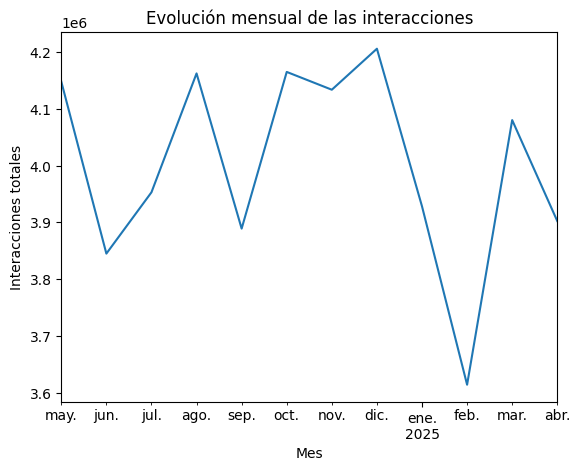

In [ ]:
#Agrupamos los datos por el número del mes y suma todas las interacciones de cada mes
interacciones_mes = df.groupby('month')['total_interactions'].sum()

interacciones_mes.plot(
    kind='line',
    title='Evolución mensual de las interacciones',
    xlabel='Mes',
    ylabel='Interacciones totales'
)

Uso este gráfico de líneas porque es la mejor forma de ver cómo han cambiado las interacciones mes a mes. Me sirve para detectar picos de actividad y ver en qué épocas del año la gente está más enganchada. Esto es clave para saber cuándo conviene lanzar campañas importantes y cuándo la participación suele bajar, para así mejorar la estrategia en los meses más flojos

In [27]:
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate,month,total_interactions
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1,2024-12,3669
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6,2024-07,2684
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4,2024-11,4037
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5,2024-09,2832
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8,2024-09,4151


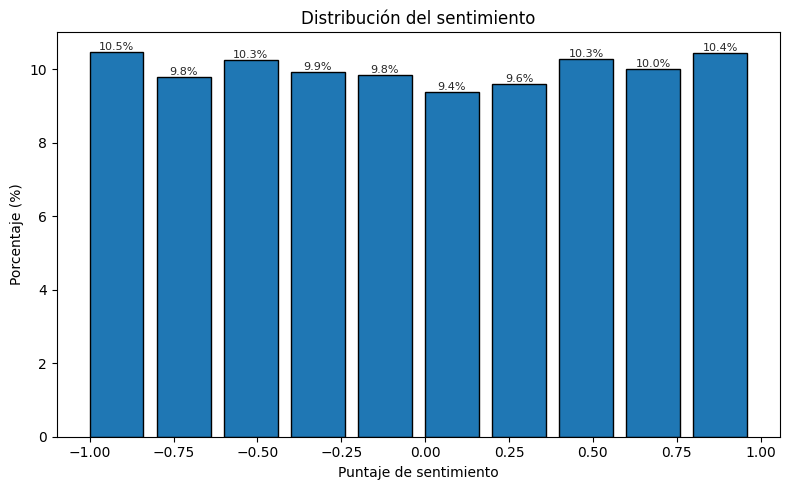

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
data = df['sentiment_score']

# Calculamos histograma y porcentajes
counts, bins = np.histogram(data, bins=10)
counts_percent = counts / counts.sum() * 100  # convertimos a %

# Ancho de cada barra
width = np.diff(bins) * 0.8  # 80% del ancho del bin para separación
x = bins[:-1]

# Gráfico
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x, counts_percent, width=width, edgecolor='black', align='edge')

# Añadimos porcentajes encima de cada barra
for xi, yi, w in zip(x, counts_percent, width):
    if yi > 0:
        ax.text(
            xi + w/2,  # centramos la barra
            yi,
            f"{yi:.1f}%",
            ha='center',
            va='bottom',
            fontsize=8,
            alpha=0.85
        )

ax.set_title('Distribución del sentimiento')
ax.set_xlabel('Puntaje de sentimiento')
ax.set_ylabel('Porcentaje (%)')
plt.tight_layout()
plt.show()

Este histograma lo uso para ver el 'humor' general de los usuarios en la red social. Al ponerlo en porcentajes, es más fácil entender qué parte del contenido es positiva, neutra o negativa. Me ayuda a saber si la mayoría de la gente está contenta con la marca o si hay un grupo de usuarios quejándose (sentimiento negativo), lo que nos daría una pista para actuar rápido antes de tener un problema de reputación

In [29]:
df['weekday'] = df['timestamp'].dt.day_name()

Creamos una nueva columna llamada weekday y que extraemos el nombre del día de la semana a partir de la columna timestamp

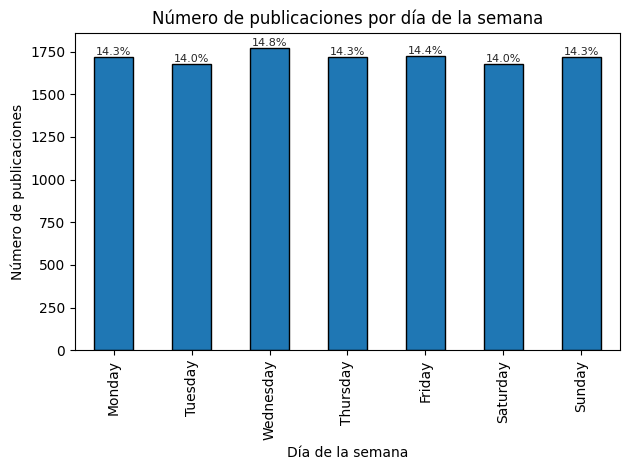

In [30]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
posts_por_dia = df['weekday'].value_counts().reindex(days_order, fill_value=0)

ax = posts_por_dia.plot(
    kind='bar',
    edgecolor='black',
    title='Número de publicaciones por día de la semana',
    xlabel='Día de la semana',
    ylabel='Número de publicaciones'
)

# Añadimos porcentaje sobre cada barra
total = posts_por_dia.sum()
for i, val in enumerate(posts_por_dia):
    if val > 0:
        porcentaje = val / total * 100
        ax.text(i, val, f"{porcentaje:.1f}%", ha='center', va='bottom', fontsize=8, alpha=0.85)

plt.tight_layout()
plt.show()

Este gráfico de barras permite desglosar la actividad de la plataforma en un ciclo semanal. No solo mide cuántas veces publicamos, sino que revela los hábitos de gestión de contenido y la presencia de la marca en el tiempo de ocio frente al tiempo laboral de los usuarios

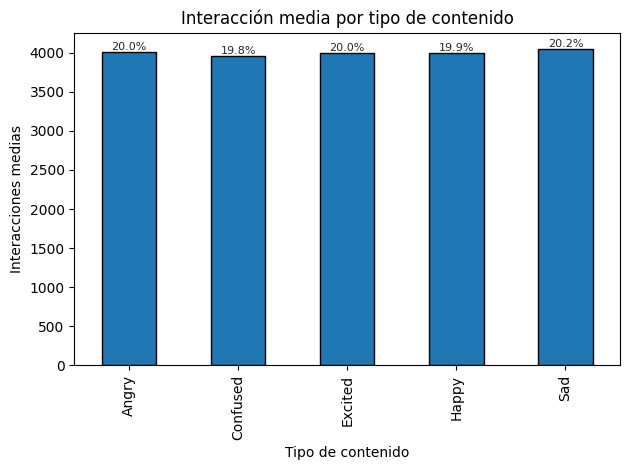

In [ ]:
interacciones_tipo = df.groupby('emotion_type')['total_interactions'].mean()
total = interacciones_tipo.sum()  # total de la media sumada para calcular % de cada tipo

# Gráfico de barras
ax = interacciones_tipo.plot(
    kind='bar',
    title='Interacción media por tipo de contenido',
    xlabel='Tipo de contenido',
    ylabel='Interacciones medias',
    edgecolor='black'
)

# Añadir porcentaje encima de cada barra
for i, val in enumerate(interacciones_tipo):
    porcentaje = (val / total) * 100
    ax.text(
        i,
        val,
        f"{porcentaje:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8,
        alpha=0.85
    )

plt.tight_layout()
plt.show()

Uso este gráfico para ver qué tipo de contenido (o emoción) funciona mejor de media. No uso el total porque si publicamos mucho de algo, el resultado nos engañaría; en cambio, la media me dice qué formato es más efectivo cada vez que lanzamos un post. Los porcentajes ayudan a ver rápido qué peso tiene cada tipo sobre el engagement total, lo que nos sirve para decidir en qué formato vale más la pena invertir tiempo y esfuerzo para que la audiencia participe más

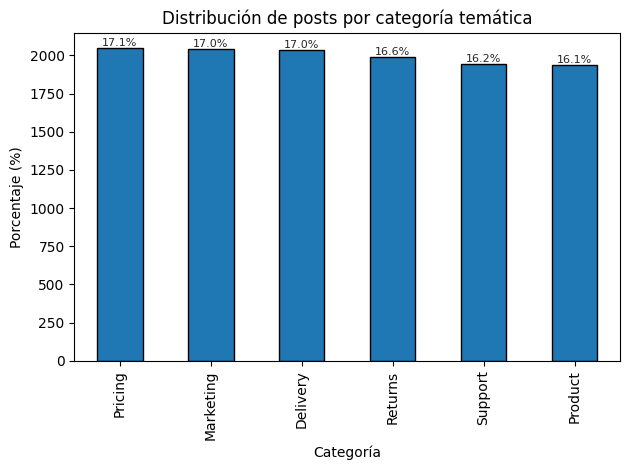

In [ ]:
topic_counts = df['topic_category'].value_counts()
total = topic_counts.sum()

# Gráfico de barras
ax = topic_counts.plot(
    kind='bar',
    title='Distribución de posts por categoría temática',
    
    edgecolor='black'
)

plt.ylabel('Porcentaje (%)')
plt.xlabel('Categoría')

# Añadimos porcentaje sobre cada barra
for i, count in enumerate(topic_counts):
    porcentaje = (count / total) * 100
    ax.text(
        i,
        count,                   # posición vertical
        f"{porcentaje:.1f}%",    # texto
        ha='center',
        va='bottom',
        fontsize=8,
        alpha=0.85
    )

plt.tight_layout()
plt.show()

Este gráfico se utiliza para analizar la distribución de las publicaciones por categoría temática en la red social. Permite identificar qué temas predominan y cuál es su proporción respecto al total, facilitando la comprensión de los intereses de los usuarios.

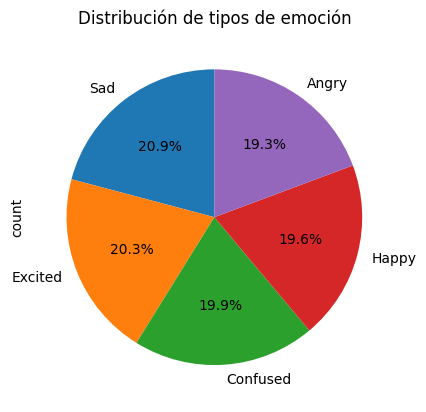

In [33]:
emotion_counts = df['emotion_type'].value_counts()

# Gráfico de pastel
ax = emotion_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    title='Distribución de tipos de emoción',
)
plt.show()

Este gráfico se utiliza para analizar la distribución de los distintos tipos de emoción presentes en las publicaciones de la red social. Permite identificar qué emociones predominan y cuál es su proporción respecto al total, facilitando una comprensión general del tono emocional del contenido

In [34]:
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate,month,total_interactions,weekday
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1,2024-12,3669,Monday
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6,2024-07,2684,Sunday
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4,2024-11,4037,Saturday
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5,2024-09,2832,Monday
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8,2024-09,4151,Thursday


In [35]:
df['hour'] = df['timestamp'].dt.hour

Sacamos la hora del día (0–23) de la fecha

In [36]:
posts_por_hora = df['hour'].value_counts().sort_index()

Contamos cuántos posts hay por hora y lo ordenamos con .sort_index

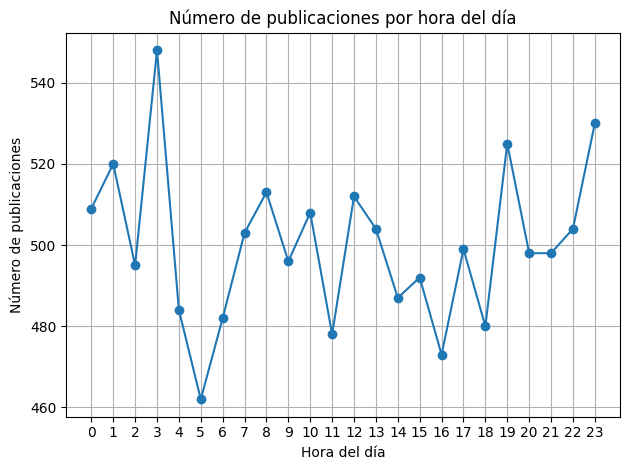

In [ ]:
ax = posts_por_hora.plot(
    kind='line',
    marker='o',
    title='Número de publicaciones por hora del día',
    xlabel='Hora del día',
    ylabel='Número de publicaciones'
)

plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

Este gráfico se utiliza para analizar la distribución de las publicaciones a lo largo de las horas del día, permitiendo identificar los momentos de mayor y menor actividad de los usuarios. Este análisis es útil para comprender los hábitos diarios de la comunidad y planificar los horarios más efectivos para publicar contenido y maximizar el alcance e interacción.

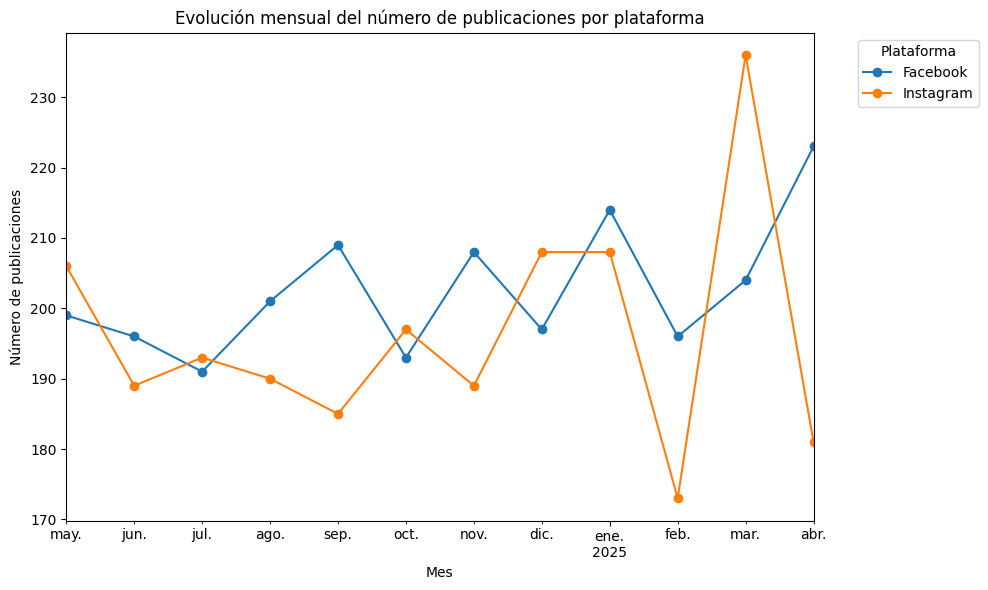

In [41]:
publicaciones_mes_plataforma_sel = publicaciones_mes_plataforma[['Facebook', 'Instagram']]

# Gráfica
ax = publicaciones_mes_plataforma_sel.plot(
    kind='line',
    marker='o',
    title='Evolución mensual del número de publicaciones por plataforma',
    xlabel='Mes',
    ylabel='Número de publicaciones',
    figsize=(10, 6)
)

plt.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

En este gráfico muestra la evolución del uso de las plataformas más utilizadas a lo largo de los meses. Cada línea representa una plataforma y nos permite ver cuáles son las más activas y cómo varía su uso con el tiempo. Por ejemplo, podemos observar picos en ciertos meses y diferencias claras entre plataformas, lo que ayuda a entender la tendencia de actividad de los usuarios en la red social.

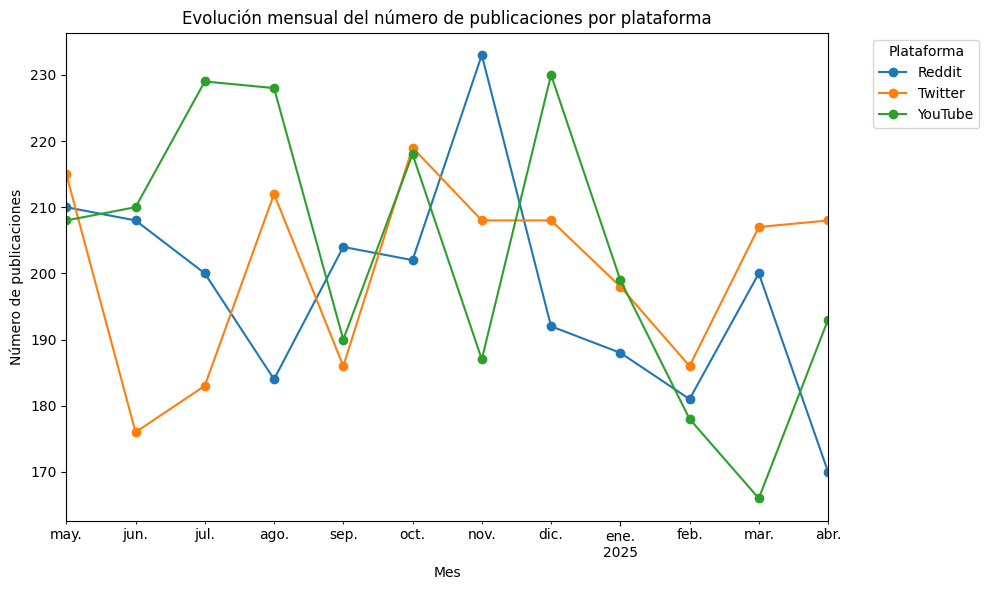

In [ ]:
publicaciones_mes_plataforma_sel = publicaciones_mes_plataforma[['Reddit', 'Twitter', 'YouTube']]

# Gráfica
ax = publicaciones_mes_plataforma_sel.plot(
    kind='line',
    marker='o',
    title='Evolución mensual del número de publicaciones por plataforma',
    xlabel='Mes',
    ylabel='Número de publicaciones',
    figsize=(10, 6)
)

plt.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

En este gráfico muestra la evolución del uso de las plataformas más utilizadas a lo largo de los meses. Cada línea representa una plataforma y nos permite ver cuáles son las más activas y cómo varía su uso con el tiempo. Por ejemplo, podemos observar picos en ciertos meses y diferencias claras entre plataformas, lo que ayuda a entender la tendencia de actividad de los usuarios en la red social.

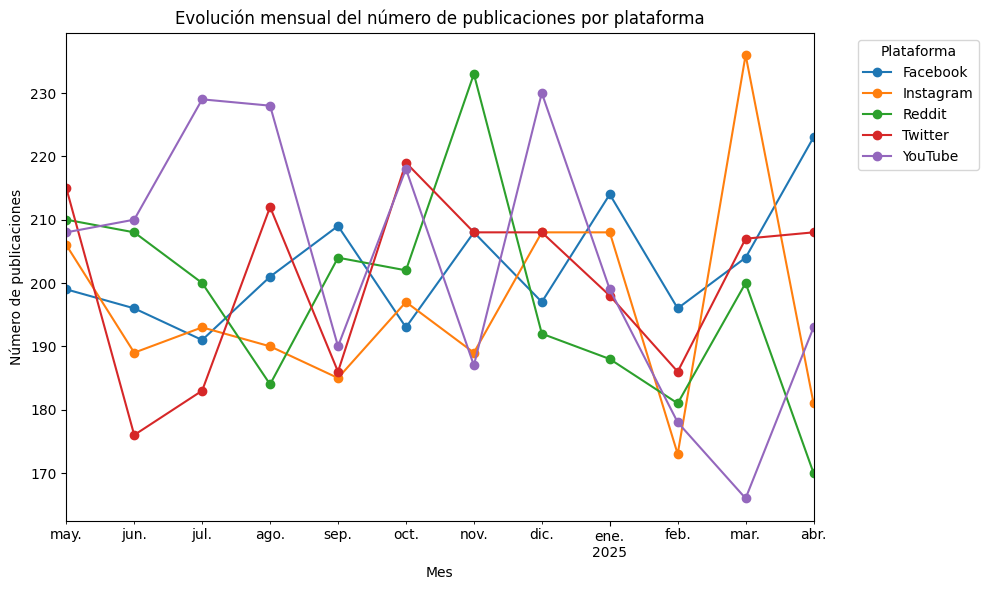

In [40]:
publicaciones_mes_plataforma = (
    df.groupby(['month', 'platform'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)


ax = publicaciones_mes_plataforma.plot(
    kind='line',
    marker='o',
    title='Evolución mensual del número de publicaciones por plataforma',
    xlabel='Mes',
    ylabel='Número de publicaciones',
    figsize=(10, 6)
)

plt.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


En este gráfico muestra la evolución del uso de las plataformas más utilizadas a lo largo de los meses. Cada línea representa una plataforma y nos permite ver cuáles son las más activas y cómo varía su uso con el tiempo. Por ejemplo, podemos observar picos en ciertos meses y diferencias claras entre plataformas, lo que ayuda a entender la tendencia de actividad de los usuarios en la red social.

Conclusion:
A partir de las visualizaciones realizadas, se observa que la actividad de los usuarios no es constante en el tiempo, existiendo meses con picos de interacción. Además, determinados tipos de contenido y campañas generan un mayor impacto, lo que sugiere la necesidad de priorizar estos formatos para mejorar el engagement de la plataforma.